In [1]:
from torch_geometric.data import Data
from tools import MeshGenerator, FrameField, NACA_airfoil, StreamlineGenerator, Transfinite_Interpolation
from tools import StreamlinePostProcessor
from tools.plotting_tools import *
import torch
import numpy as np
from numba import jit, prange
from scipy.optimize import minimize
from scipy.interpolate import splev, splprep
from typing import List
import matplotlib.pyplot as plt


In [2]:

class StreamlineIntersectionSplitter:
    def __init__(self, offset_boundingBox=0.05, num_samples=5, tolerance=1e-8):
        self.offset_boundingBox = offset_boundingBox
        self.num_samples = num_samples
        self.tolerance = tolerance
    
    def process_streamlines(self, streamlines: List):
        """Main method to find intersections and split streamlines."""
        splines = self.get_streamlines_as_splines(streamlines)
        split_points = self.find_all_intersections(splines)
        new_splines = self.split_streamlines(splines, split_points)
        return self.splines_to_points(new_splines)
        
    def find_all_intersections(self, splines):
        """Find all intersection points between streamlines."""
        split_points = {i: [] for i in range(len(splines))}
        
        for i in range(len(splines)):
            for j in range(i + 1, len(splines)):
                if self.check_endpoints_match(splines[i], splines[j]):
                    continue
                
                intersection = self.find_intersection(splines[i], splines[j])
                if intersection:
                    t1, t2 = intersection
                    split_points[i].append(t1)
                    split_points[j].append(t2)
        
        return split_points
    
    def find_intersection(self, spline1, spline2):
        """Find intersection between two splines."""
        tck1, u1 = spline1
        tck2, u2 = spline2
        
        u1_fine = np.linspace(0, 1, self.num_samples)
        u2_fine = np.linspace(0, 1, self.num_samples)
        points1 = np.array(splev(u1_fine, tck1)).T
        points2 = np.array(splev(u2_fine, tck2)).T
        
        potential = self.check_bounding_boxes(points1, points2, u1_fine, u2_fine)
        if len(potential) > 0:
            return self.confirm_intersection(potential, tck1, tck2)
        return None
    
    def check_endpoints_match(self, spline1, spline2):
        """Check if splines share endpoints."""
        tck1, _ = spline1
        tck2, _ = spline2
        
        p1_start = np.array(splev(0, tck1))
        p1_end = np.array(splev(1, tck1))
        p2_start = np.array(splev(0, tck2))
        p2_end = np.array(splev(1, tck2))
        
        return (np.allclose(p1_start, p2_start, atol=self.tolerance) or 
                np.allclose(p1_start, p2_end, atol=self.tolerance) or
                np.allclose(p1_end, p2_start, atol=self.tolerance) or 
                np.allclose(p1_end, p2_end, atol=self.tolerance))
    
    def confirm_intersection(self, potential_intersections, tck1, tck2):
        """Optimize to confirm actual intersection."""
        for u1_init, u2_init in potential_intersections:
            dist = lambda t: np.sum((np.array(splev(t[0], tck1)) - 
                                    np.array(splev(t[1], tck2)))**2)
            res = minimize(dist, [u1_init, u2_init], 
                         bounds=[(0,1), (0,1)], method='L-BFGS-B')
            if res.fun < self.tolerance:
                return (res.x[0], res.x[1])
        return None
        
    def splines_to_points(self, splines, num_points=100):
        """Convert splines back to point arrays."""
        result = []
        for spline in splines:
            tck, u = spline  # Now this works with lists [tck, u]
            u_eval = np.linspace(0, 1, num_points)
            points = np.array(splev(u_eval, tck)).T
            result.append(points)
        return result

    def split_streamlines(self, splines, split_points):
        """Split streamlines at intersection points."""
        result = []
        
        for i, spline in enumerate(splines):
            if not split_points[i]:
                result.append(spline)  # This is [tck, u] list
            else:
                splits = sorted(split_points[i])
                tck, u = spline
                
                splits = [0] + [t for t in splits if 0.001 < t < 0.999] + [1]
                
                for k in range(len(splits) - 1):
                    t_start = splits[k]
                    t_end = splits[k + 1]
                    
                    t_sub = np.linspace(t_start, t_end, 20)
                    points_sub = np.array(splev(t_sub, tck))
                    
                    if points_sub.shape[1] > 3:
                        tck_new, u_new = splprep(points_sub, s=0)
                        result.append([tck_new, u_new]) 
    
        return result
            
    def check_bounding_boxes(self, points1, points2, u1_fine, u2_fine):
        """Wrapper for parallel bounding box check."""
        return check_bounding_boxes_parallel(points1, points2, u1_fine, u2_fine, 
                                             self.offset_boundingBox)
    
    def get_streamlines_as_splines(self, streamlines):

        splines = []

        for i in range(len(streamlines)):
            streamline = np.array(streamlines[i])
            x = streamline[:, 0]
            y = streamline[:, 1]
            if x.size == 2:
                tck, u = splprep([x, y], s=0, k=1)  # k=1 linear splines
                splines.append([tck, u])
            else:
                tck, u = splprep([x, y], s=0)  # Cubic Splines (Default)
                splines.append([tck, u])

        return splines

# Standalone parallel function (can't be a class method with numba)
@jit(nopython=True, parallel=True)
def check_bounding_boxes_parallel(points1, points2, u1_fine, u2_fine, offset_boundingBox):
    n1 = len(points1) - 1
    n2 = len(points2) - 1
    results = np.zeros((n1 * n2, 2))
    
    for idx in prange(n1 * n2):
        i = idx // n2
        j = idx % n2
        
        min_x1, max_x1 = min(points1[i][0], points1[i+1][0]), max(points1[i][0], points1[i+1][0])
        min_y1, max_y1 = min(points1[i][1], points1[i+1][1]), max(points1[i][1], points1[i+1][1])
        min_x2, max_x2 = min(points2[j][0], points2[j+1][0]), max(points2[j][0], points2[j+1][0])
        min_y2, max_y2 = min(points2[j][1], points2[j+1][1]), max(points2[j][1], points2[j+1][1])
        
        min_x11 = min_x1 - max(offset_boundingBox, offset_boundingBox * abs(min_x1))
        max_x11 = max_x1 + max(offset_boundingBox, offset_boundingBox * abs(max_x1))
        min_y11 = min_y1 - max(offset_boundingBox, offset_boundingBox * abs(min_y1))
        max_y11 = max_y1 + max(offset_boundingBox, offset_boundingBox * abs(max_y1))
        min_x22 = min_x2 - max(offset_boundingBox, offset_boundingBox * abs(min_x2))
        max_x22 = max_x2 + max(offset_boundingBox, offset_boundingBox * abs(max_x2))
        min_y22 = min_y2 - max(offset_boundingBox, offset_boundingBox * abs(min_y2))
        max_y22 = max_y2 + max(offset_boundingBox, offset_boundingBox * abs(max_y2))
        
        if (min_x11 <= max_x22 and max_x11 >= min_x22 and
            min_y11 <= max_y22 and max_y11 >= min_y22):
            results[idx] = [u1_fine[i], u2_fine[j]]
        else:
            results[idx] = [-1, -1]
    
    return results[results[:, 0] >= 0]


In [3]:
import numpy as np
import torch

def build_connectivity(streamlines, tol=1e-2):
    # Collect all unique nodes
    nodes = {}
    for s in streamlines:
        for p in [tuple(s[0]), tuple(s[-1])]:
            if not any(np.allclose(p, n, atol=tol) for n in nodes):
                nodes[p] = len(nodes)
    
    # Build edges and flip duplicates
    node_list = list(nodes.keys())
    edges = []  # [start_node, end_node] pairs
    used_pairs = set()
    processed_streamlines = []  # Store potentially flipped streamlines
    edges_to_streamline = {}
    for i, s in enumerate(streamlines):
        start_idx = next(j for j, n in enumerate(node_list) if np.allclose(s[0], n, atol=tol))
        end_idx = next(j for j, n in enumerate(node_list) if np.allclose(s[-1], n, atol=tol))
     
        # Check if this node pair already exists
        if (start_idx, end_idx) in used_pairs:
            # Flip the streamline
            streamline_reversed = s[::-1]
            processed_streamlines.append(streamline_reversed)  # Reverse the streamline
            edges.append([end_idx, start_idx])
            used_pairs.add((end_idx, start_idx))
            edges_to_streamline[(end_idx, start_idx)] = streamline_reversed
        else:
            processed_streamlines.append(s)  # Keep original
            edges.append([start_idx, end_idx])
            used_pairs.add((start_idx, end_idx))
            edges_to_streamline[(start_idx,end_idx)] = s

    
    return (torch.tensor(node_list),           # (n_nodes, 2)
            torch.tensor(edges).T,            
            edges_to_streamline,
            processed_streamlines)             



In [4]:
def get_quad_faces(edges):
    import networkx as nx
    Edges = []
    for e in range(edges.size(1)):
        Edges.append((edges[0,e].item(),edges[1,e].item()))
    
    graph = nx.Graph()
    graph.add_edges_from(Edges)
    faces_raw = list(nx.simple_cycles(graph, length_bound=4))
    
    quad_faces = []
    for i in range(len(faces_raw)):
        face = faces_raw[i]
        if len(face) == 4:
            quad_faces.append(face)
            
    return torch.tensor(quad_faces).T

In [13]:
def sort_faces_ccw(faces, nodes):
    sorted_faces = faces.clone()
    
    for i in range(faces.size(1)):
        face = faces[:, i]
        coords = nodes[face, :].numpy()
        
        # Shoelace formula for signed area
        signed_area = 0
        for j in range(4):
            k = (j + 1) % 4
            signed_area += coords[j, 0] * coords[k, 1] - coords[k, 0] * coords[j, 1]
        
        # If clockwise (negative area), flip the face
        if signed_area < 0:
            sorted_faces[:, i] = torch.flip(face, [0])
    
    return sorted_faces

In [23]:
from torch_geometric.transforms import FaceToEdge

In [28]:
def faces_to_edges(face):
    
    if face.size()[0] == 3:
            edge_index = torch.cat([
                face[:2],
                face[1:],
                face[::2],
            ], dim=1)
    else:
            assert face.size()[0] == 4
            edge_index = torch.cat([
                face[:2],
                face[1:3],
                face[2:4],
                face[::2],
                face[1::2],
                face[::3],
            ], dim=1)
    return edge_index

In [29]:
edges = faces_to_edges(sorted_faces)

In [30]:
edges

tensor([[ 0,  1, 11, 11,  4, 10,  1,  2, 10,  3,  5,  6, 11,  3,  8,  4,  6,  7,
          0,  1, 11, 11,  4, 10,  1,  2, 10,  3,  5,  6,  0,  1, 11, 11,  4, 10],
        [ 1,  2, 10,  3,  5,  6, 11,  3,  8,  4,  6,  7,  9, 11,  9, 10, 10,  8,
         11,  3,  8,  4,  6,  7,  9, 11,  9, 10, 10,  8,  9, 11,  9, 10, 10,  8]])

In [20]:
def map_face_edges_streamline(faces, nodes, edge_streamline_mapping):
   face_edge_to_streamline = {}
   
   for i in range(faces.size(1)):
       face = faces[:, i]
       face_nodes = nodes[face, :]
       center = torch.mean(face_nodes, dim=0)
       
       for j in range(4):
           start = face[j].item()
           end = face[(j+1) % 4].item()
           edge = (start, end)
           edge_reversed = (end, start)
           
           candidates = []
           if edge in edge_streamline_mapping:
               candidates.append(edge_streamline_mapping[edge])
           if edge_reversed in edge_streamline_mapping:
               candidates.append(edge_streamline_mapping[edge_reversed][::-1].copy())
           
           if len(candidates) == 1:
               face_edge_to_streamline[edge] = candidates[0]
           elif len(candidates) > 1:
               best_distance = torch.inf
               best_streamline = None
               
               for candidate in candidates:
                   # candidate_tensor = torch.tensor(candidate, dtype=torch.float32)
                   candidate_tensor = torch.from_numpy(candidate.copy()).float()
                   distances = torch.linalg.norm(candidate_tensor - center.unsqueeze(0), dim=1)
                   min_distance = torch.min(distances)
                   
                   if min_distance < best_distance:
                       best_distance = min_distance
                       best_streamline = candidate
               
               face_edge_to_streamline[edge] = best_streamline
   
   return face_edge_to_streamline

In [24]:
sorted_faces.size()

torch.Size([4, 6])

In [14]:
mesh                        = torch.load('simple_mesh.pt', weights_only=False)
mesh_pp                     = mesh
streamlines_post_processed  = StreamlinePostProcessor(mesh)
splitter                    = StreamlineIntersectionSplitter(offset_boundingBox=0.05, num_samples=5)
updated_streamlines         = splitter.process_streamlines(streamlines_post_processed.new_streamlines)

nodes, edges, edges_to_streamline,updated_streamlines  = build_connectivity(updated_streamlines)

faces                       = get_quad_faces(edges)
sorted_faces                = sort_faces_ccw(faces, nodes)
face_edge_to_streamline     = map_face_edges_streamline_debug(sorted_faces,nodes,edges_to_streamline)
# mesh_pp.streamlines         = updated_streamlines

# mesh_pp.faces = faces
# plot_streamlines(mesh_pp)


 function pre_processing 


 started function merge_streamlines


 started function search_duplicated_streamlines


 found 0 streamlines to merge

Searching for intersections...


/mnt/scratch/trentschler/repos/domain_partition/tools/streamline_post_processor.py:949: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  t1_intersect, t2_intersect = fsolve(distance_func, initial_guess)


In [15]:
sorted_faces = sort_faces_ccw(faces, nodes)

\n=== FACE 2, EDGE 0 (11→10) ===
Face center: tensor([0.2012, 0.5014], dtype=torch.float64)
\nKandidat 0 (direct):
  Streamline shape: (100, 2)
  First point: [0.25138471 0.07378932]
  Last point: [0.55331587 0.88979401]
  Min distance: 0.202173 (at point index 44)
  Mean distance: 0.312943
  Closest point: [0.39265038 0.43654191]
  Current best distance: inf
  This distance: 0.202173
  Is this better? True
  *** NEW BEST: Kandidat 0 with distance 0.202173 ***
\nKandidat 1 (reversed):
  Streamline shape: (100, 2)
  First point: [0.25138471 0.07378932]
  Last point: [0.55331587 0.88979401]
  Min distance: 0.284753 (at point index 38)
  Mean distance: 0.370885
  Closest point: [0.44961824 0.36229414]
  Current best distance: 0.202173
  This distance: 0.284753
  Is this better? False
\nFINAL SELECTION:
  Chosen: Kandidat 0 (direct) with distance 0.202173


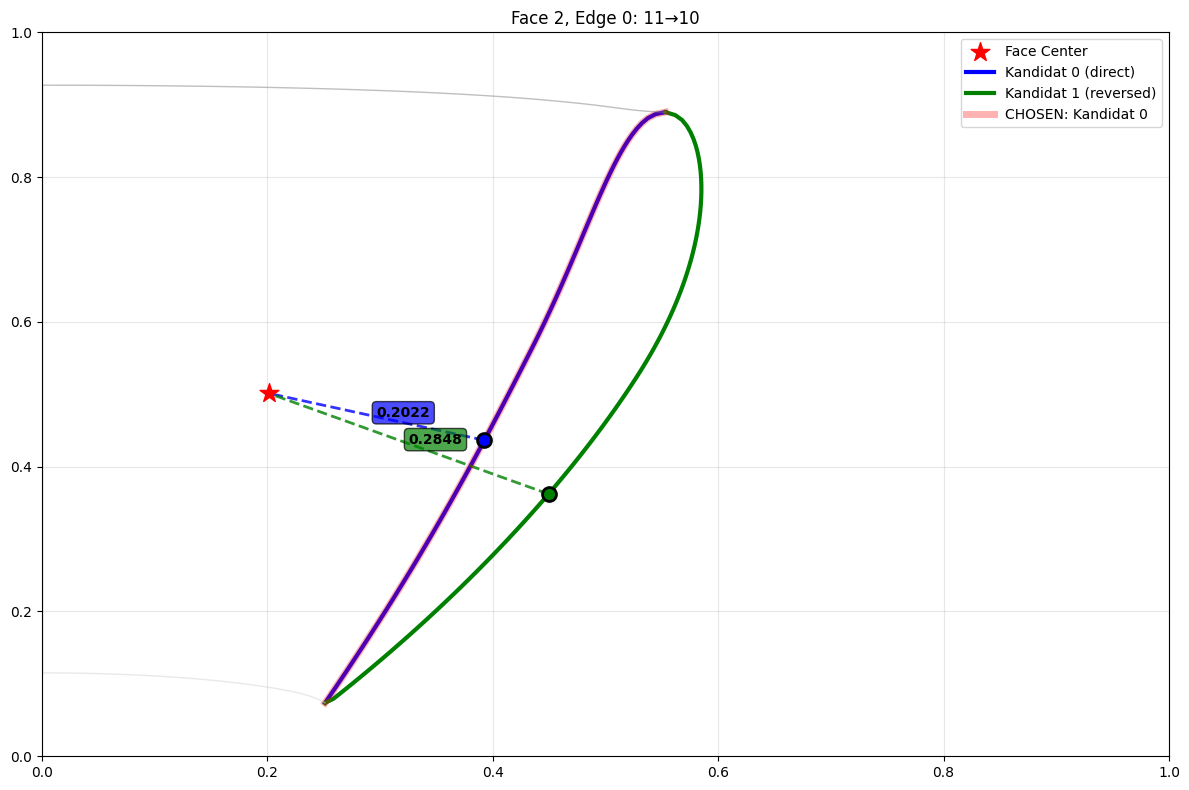

\n=== FACE 3, EDGE 3 (10→11) ===
Face center: tensor([0.7012, 0.4690], dtype=torch.float64)
\nKandidat 0 (direct):
  Streamline shape: (100, 2)
  First point: [0.55331587 0.88979401]
  Last point: [0.25138471 0.07378932]
  Min distance: 0.181327 (at point index 40)
  Mean distance: 0.328809
  Closest point: [0.53315247 0.53720485]
  Current best distance: inf
  This distance: 0.181327
  Is this better? True
  *** NEW BEST: Kandidat 0 with distance 0.181327 ***
\nKandidat 1 (reversed):
  Streamline shape: (100, 2)
  First point: [0.55331587 0.88979401]
  Last point: [0.25138471 0.07378932]
  Min distance: 0.282524 (at point index 41)
  Mean distance: 0.382809
  Closest point: [0.43176575 0.55410816]
  Current best distance: 0.181327
  This distance: 0.282524
  Is this better? False
\nFINAL SELECTION:
  Chosen: Kandidat 0 (direct) with distance 0.181327


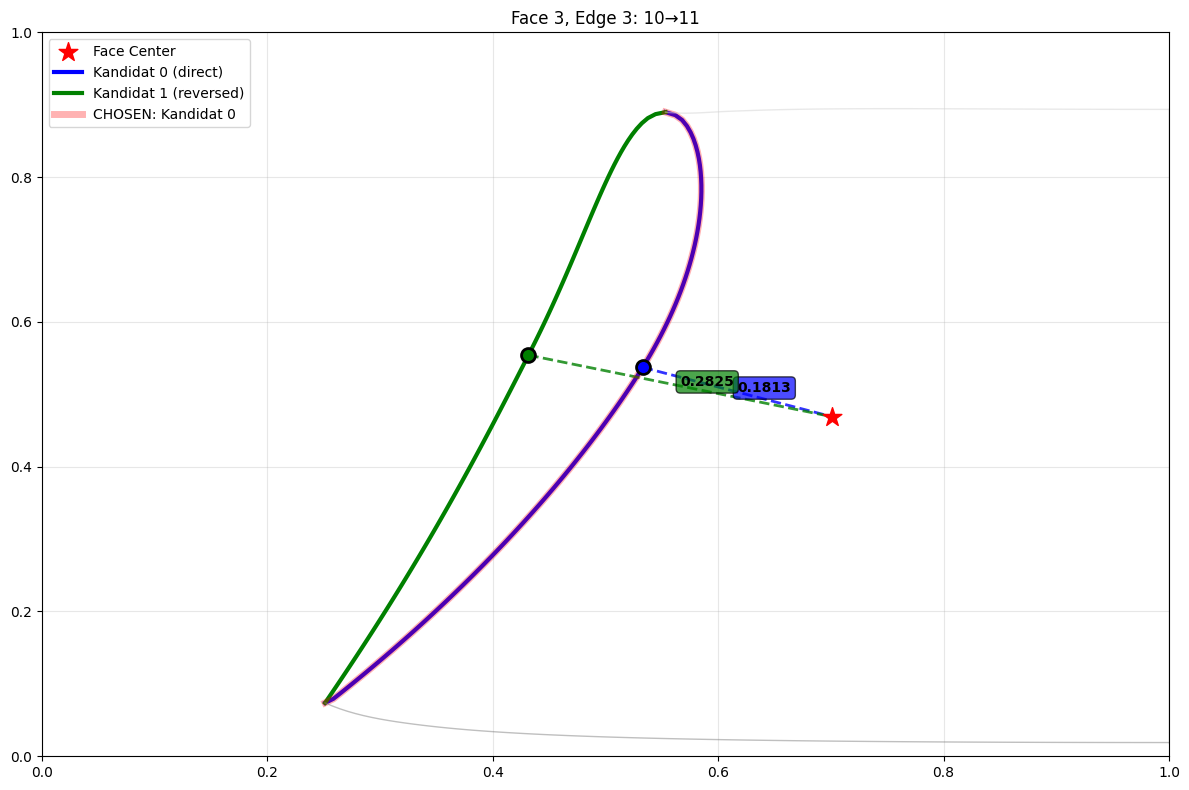

In [16]:
face_edge_to_streamline = map_face_edges_streamline_debug(sorted_faces,nodes,edges_to_streamline)

tensor([0.2012, 0.5014], dtype=torch.float64)


ValueError: At least one stride in the given numpy array is negative, and tensors with negative strides are not currently supported. (You can probably work around this by making a copy of your array  with array.copy().) 

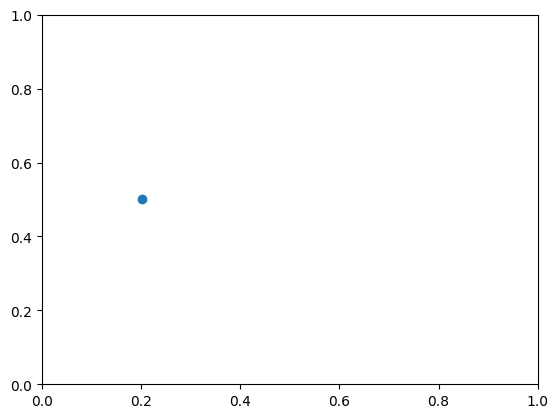

In [20]:
face_edge_to_streamline     = map_face_edges_streamline(sorted_faces,nodes,edges_to_streamline)

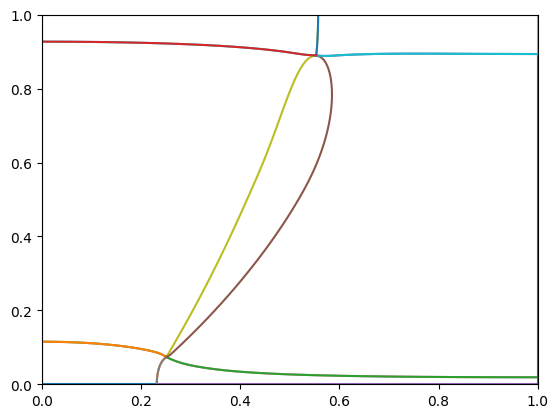

In [18]:
plt.figure()
plt.xlim(0,1)
plt.ylim(0,1)
for key in face_edge_to_streamline.keys():
    s = face_edge_to_streamline[key]
    plt.plot(s[:,0],s[:,1])

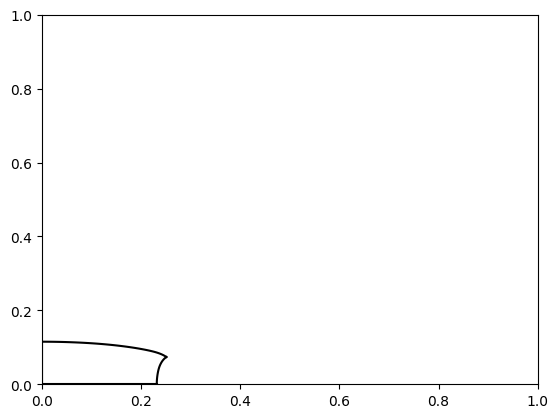

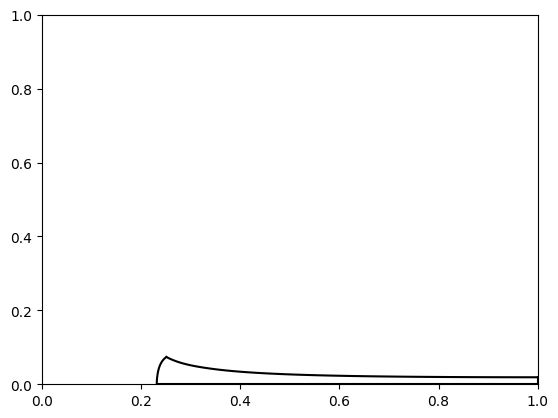

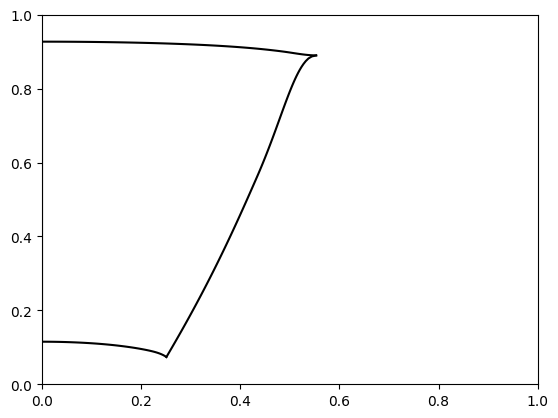

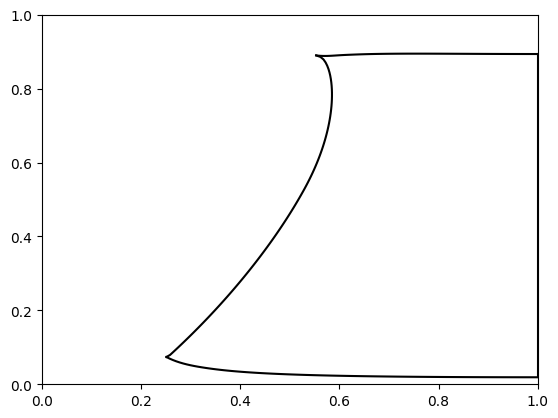

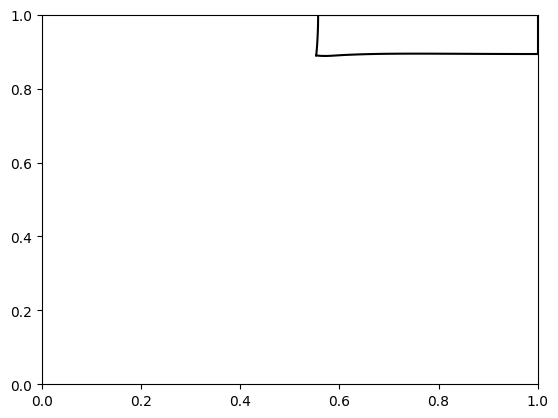

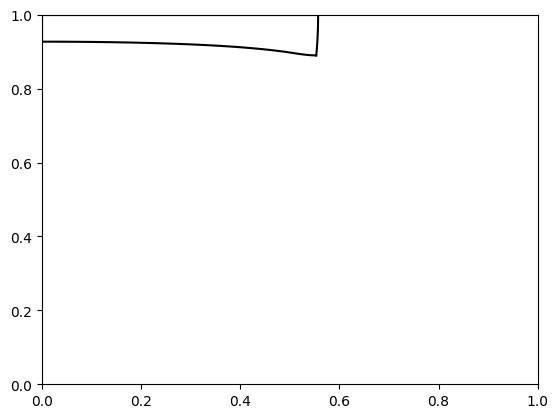

In [21]:

for i in range(sorted_faces.size(1)):
        plt.figure()
        plt.xlim(0,1)
        plt.ylim(0,1)
        face = sorted_faces[:,i]
        for j in range(4):
            idx_1 = j
            idx_2 = (j+1)%4
            start = face[idx_1].item()
            end = face[idx_2].item()
            
            edge = (start,end)
            edge_reversed = (end,start)
            streamline  = face_edge_to_streamline[edge]
            plt.plot(streamline[:,0],streamline[:,1],'k')

In [10]:
import matplotlib.pyplot as plt

In [ ]:
def map_face_edges_streamline(faces,nodes,edge_streamline_mapping):
    
    face_edge_to_streamline = {}
    
    for i in range(faces.size(1)):
        
        face = faces[:,i]
        for j in range(4):
            idx_1 = j
            idx_2 = (j+1)%4
            start = face[idx_1].item()
            end = face[idx_2].item()
            
            edge = (start,end)
            edge_reversed = (end,start)
            candidate_streamlines = []
                
            if edge in edge_streamline_mapping:
                
                streamline  = edge_streamline_mapping[edge]
                candidate_streamlines.append(edge_streamline_mapping[edge])
    
            if edge_reversed in edge_streamline_mapping:
            
                streamline_reversed = edge_streamline_mapping[edge_reversed][::-1] 
                candidate_streamlines.append(streamline_reversed)
    
            if len(candidate_streamlines) == 1:
                    best_streamline = candidate_streamlines[0]
                    
            elif (len(candidate_streamlines)) == 2:
                
                plt.figure()
                plt.xlim(0,1)
                plt.ylim(0,1)
                
                for ii in range(4):
                    idx_1 = j
                    idx_2 = (j+1)%4
                    start = face[idx_1].item()
                    end = face[idx_2].item()
                    
                    edge = (start,end)
                    edge_reversed = (end,start)
                    
                    if edge in edge_streamline_mapping:
                        streamline  = edge_streamline_mapping[edge]
                        plt.plot(streamline[0,:],plt.plot(streamline[1,:],'k')

                    if edge_reversed in edge_streamline_mapping:
                        streamline_reversed = edge_streamline_mapping[edge_reversed][::-1] 
                        plt.plot(streamline_reversed[0,:],plt.plot(streamline_reversed[1,:],'b')
                
    #             streamline  = edge_streamline_mapping[edge]

                
    #             best_distance = torch.inf
                
    #             saved_k = None
                
    #             for k in range(len(candidate_streamlines)):
    #                 plt.plot(candidate_streamlines[k][0,:],candidate_streamlines[k][1,:])
    #                 face_nodes = nodes[face,:]
    #                 center = torch.mean(face_nodes,dim=0)
                    
    #                 plt.plot(center[0],center[1],'r')
                    
    #                 distance =torch.linalg.norm(torch.from_numpy(candidate_streamlines[k])-center,axis=1)
    #                 distance_min_idx = torch.argmin(distance)
    #                 distance_min = distance[distance_min_idx]
    #                 print(distance_min)
    #                 plt.plot(candidate_streamlines[k][distance_min_idx,0],candidate_streamlines[k][distance_min_idx,1],'b')

                    
    #                 if distance_min<best_distance:
    #                     best_distance = distance_min
    #                     saved_k = k
    #             best_streamline =    candidate_streamlines[saved_k]
    #         face_edge_to_streamline[edge] = best_streamline
    # return face_edge_to_streamline

In [9]:
def map_face_edges_streamline(faces,nodes,edge_streamline_mapping):
    
    face_edge_to_streamline = {}
    
    for i in range(faces.size(1)):
        
        face = faces[:,i]
        for j in range(4):
            idx_1 = j
            idx_2 = (j+1)%4
            start = face[idx_1].item()
            end = face[idx_2].item()
            
            edge = (start,end)
            edge_reversed = (end,start)
            candidate_streamlines = []
                
            if edge in edge_streamline_mapping:
                
                candidate_streamlines.append(edge_streamline_mapping[edge])
    
            if edge_reversed in edge_streamline_mapping:
            
                candidate_streamlines.append(edge_streamline_mapping[edge_reversed][::-1] )
    
            if len(candidate_streamlines) == 1:
                
                    best_streamline               = candidate_streamlines[0]
                    face_edge_to_streamline[edge] = best_streamline
                
                   
            elif (len(candidate_streamlines)) >1:
                
                plt.figure()
                plt.xlim(0,1)
                plt.ylim(0,1)
                face_nodes    = nodes[face,:]
                center        = torch.mean(face_nodes,dim=0)
                best_distance = torch.inf 
                saved_idx     = None
                
                print(center)
                plt.scatter(center[0],center[1])
                for k in range(len(candidate_streamlines)):
                    candidate = candidate_streamlines[k] 
                    distance  = torch.linalg.norm(torch.from_numpy(candidate)-center,axis=1)
                    distance_min_idx = torch.argmin(distance)
                    distance_min = distance[distance_min_idx]
                    
                    x1 = candidate[distance_min_idx,0]
                    x2 = center[0]

                    y1 = candidate[distance_min_idx,1]
                    y2 = center[1]
                    plt.plot([x1, x2], [y1, y2])

                    if distance_min <best_distance:
                        best_distance = distance_min
                        saved_idx = k
                best_streamline = candidate_streamlines[saved_idx] 
                face_edge_to_streamline[edge] = best_streamline

                for ii in range(4):
                    idx_1 = ii
                    idx_2 = (ii+1)%4
                    start = face[idx_1].item()
                    end = face[idx_2].item()
                    
                    edge = (start,end)
                    edge_reversed = (end,start)
                    
                    if edge in edge_streamline_mapping:
                        streamline  = edge_streamline_mapping[edge]
                        plt.plot(streamline[:,0],streamline[:,1],'k')

                    if edge_reversed in edge_streamline_mapping:
                        streamline_reversed = edge_streamline_mapping[edge_reversed][::-1] 
                        plt.plot(streamline_reversed[:,0],streamline_reversed[:,1],'b')
                    

    return face_edge_to_streamline

In [12]:
def map_face_edges_streamline_debug(faces, nodes, edge_streamline_mapping):
    
    face_edge_to_streamline = {}
    
    for i in range(faces.size(1)):
        
        face = faces[:, i]
        for j in range(4):
            start = face[j].item()
            end = face[(j+1) % 4].item()
            
            edge = (start, end)
            edge_reversed = (end, start)
            candidate_streamlines = []
            candidate_labels = []  # Track which is which
                
            if edge in edge_streamline_mapping:
                candidate_streamlines.append(edge_streamline_mapping[edge])
                candidate_labels.append('direct')
    
            if edge_reversed in edge_streamline_mapping:
                candidate_streamlines.append(edge_streamline_mapping[edge_reversed][::-1])
                candidate_labels.append('reversed')
    
            if len(candidate_streamlines) == 1:
                best_streamline = candidate_streamlines[0]
                face_edge_to_streamline[edge] = best_streamline
                   
            elif len(candidate_streamlines) > 1:
                
                print(f"\\n=== FACE {i}, EDGE {j} ({start}→{end}) ===")
                
                plt.figure(figsize=(12, 8))
                plt.xlim(0, 1)
                plt.ylim(0, 1)
                plt.title(f'Face {i}, Edge {j}: {start}→{end}')
                
                face_nodes = nodes[face, :]
                center = torch.mean(face_nodes, dim=0)
                best_distance = torch.inf 
                saved_idx = None
                
                print(f"Face center: {center}")
                plt.scatter(center[0], center[1], c='red', s=200, marker='*', 
                           label='Face Center', zorder=10)
                
                # Debug: Analysiere jeden Kandidaten detailliert
                colors = ['blue', 'green', 'orange', 'purple']
                
                for k in range(len(candidate_streamlines)):
                    candidate = candidate_streamlines[k]
                    label = candidate_labels[k]
                    color = colors[k % len(colors)]
                    
                    print(f"\\nKandidat {k} ({label}):")
                    print(f"  Streamline shape: {candidate.shape}")
                    print(f"  First point: {candidate[0]}")
                    print(f"  Last point: {candidate[-1]}")
                    

                    candidate_tensor = torch.from_numpy(candidate.copy()).float()
                    
                    # Berechne alle Abstände
                    distances = torch.linalg.norm(candidate_tensor - center.unsqueeze(0), dim=1)
                    distance_min_idx = torch.argmin(distances)
                    distance_min = distances[distance_min_idx]
                    distance_mean = torch.mean(distances)
                    
                    print(f"  Min distance: {distance_min:.6f} (at point index {distance_min_idx})")
                    print(f"  Mean distance: {distance_mean:.6f}")
                    print(f"  Closest point: {candidate[distance_min_idx]}")
                    
                    # Plot Stromlinie
                    plt.plot(candidate[:, 0], candidate[:, 1], color=color, 
                            linewidth=3, label=f'Kandidat {k} ({label})')
                    
                    # Plot nächsten Punkt
                    closest_point = candidate[distance_min_idx]
                    plt.scatter(closest_point[0], closest_point[1], 
                               c=color, s=100, marker='o', 
                               edgecolors='black', linewidth=2, zorder=8)
                    
                    # Verbindungslinie
                    plt.plot([closest_point[0], center[0]], 
                            [closest_point[1], center[1]], 
                            color=color, linestyle='--', linewidth=2, alpha=0.8)
                    
                    # Annotiere Distanz
                    mid_x = (closest_point[0] + center[0]) / 2
                    mid_y = (closest_point[1] + center[1]) / 2
                    plt.annotate(f'{distance_min:.4f}', (mid_x, mid_y), 
                                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                                fontsize=10, fontweight='bold')
                    
                    # Vergleich für Auswahl
                    print(f"  Current best distance: {best_distance:.6f}")
                    print(f"  This distance: {distance_min:.6f}")
                    print(f"  Is this better? {distance_min < best_distance}")
                    
                    if distance_min < best_distance:
                        best_distance = distance_min
                        saved_idx = k
                        print(f"  *** NEW BEST: Kandidat {k} with distance {distance_min:.6f} ***")
                
                print(f"\\nFINAL SELECTION:")
                print(f"  Chosen: Kandidat {saved_idx} ({candidate_labels[saved_idx]}) with distance {best_distance:.6f}")
                
                # Markiere gewählte Stromlinie
                if saved_idx is not None:
                    chosen_candidate = candidate_streamlines[saved_idx]
                    plt.plot(chosen_candidate[:, 0], chosen_candidate[:, 1], 
                            'red', linewidth=5, alpha=0.3, 
                            label=f'CHOSEN: Kandidat {saved_idx}')
                
                # Plot alle anderen Stromlinien des Faces (grau)
                for ii in range(4):
                    if ii == j:  # Skip current edge
                        continue
                        
                    start_ii = face[ii].item()
                    end_ii = face[(ii+1) % 4].item()
                    
                    edge_ii = (start_ii, end_ii)
                    edge_reversed_ii = (end_ii, start_ii)
                    
                    if edge_ii in edge_streamline_mapping:
                        streamline = edge_streamline_mapping[edge_ii]
                        plt.plot(streamline[:, 0], streamline[:, 1], 'gray', 
                                alpha=0.5, linewidth=1)
                    if edge_reversed_ii in edge_streamline_mapping:
                        streamline_reversed = edge_streamline_mapping[edge_reversed_ii][::-1] 
                        plt.plot(streamline_reversed[:, 0], streamline_reversed[:, 1], 'lightgray', 
                                alpha=0.5, linewidth=1)
                
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
                # Speichere Auswahl
                if saved_idx is not None:
                    best_streamline = candidate_streamlines[saved_idx] 
                    face_edge_to_streamline[edge] = best_streamline
                else:
                    print("ERROR: No valid candidate selected!")
    
    return face_edge_to_streamline
